# Busy Airports: Predicting TSA Traffic at Major U.S. Airports

**Team members**: [David Friedenberg](https://github.com/friedenberg12), [Agniva Dasgupta](https://github.com/adg1016), [Charuhas Shiveshwarkar](https://github.com/SChars), [Ivan Caro Terrazas](https://github.com/icaromx), [Ahmad Shamloumehr](https://github.com/)

This notebook uses the TSA hourly passenger throughput dataset to build a machine learning workflow for short-term load forecasting.

## Workflow
1. Load and preprocess the dataset

## Pipeline overview

Raw data → Preprocessing → Train/Test Split → Model Training → Evaluation

## Models compared
- SARIMA
- Harmonic Regression
- STL decomposition

The goal is not only to obtain strong predictive performance, but also to keep the pipeline clear, modular, and reproducible.

## Imports

In [1]:
# Import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

# Import custom module from src/ directory
from busy_airports.preprocessing import load_data, retrieve_airport_data

# from scipy.stats import boxcox
# from scipy.special import inv_boxcox

## Data loading and preprocessing

The TSA dataset is loaded and column names are renamed to an easier way to parse them.

In [2]:
tsa_data = load_data("data/tsa-throughput-data-complete.csv")
print('Rows:', len(tsa_data), 'Columns:', tsa_data.shape[1])
mem = tsa_data.memory_usage(deep=True).sum() / (1024**2)
print(f'Memory MB: {mem:.2f}')
display(tsa_data.head(3))
display(tsa_data.tail(3))
display(tsa_data.describe(include='all').T)

Rows: 11054590 Columns: 10
Memory MB: 1658.81


,datetime,airport_code,airport_name,city,state,checkpoint,total_passenger_throughput,date,month,week
0,2022-01-01,ANC,Ted Stevens Anchorage International,Anchorage,AK,South Checkpoint,62,2022-01-01,1,52
1,2022-01-01,ATL,Hartsfield Atlanta International,Atlanta,GA,Main Checkpoint,17,2022-01-01,1,52
2,2022-01-01,BFL,"Meadows Field, Bakersfield",Bakersfield,CA,BFL01,0,2022-01-01,1,52


,datetime,airport_code,airport_name,city,state,checkpoint,total_passenger_throughput,date,month,week
11054587,2025-12-31 23:00:00,SMF,Sacramento International,Sacramento,CA,Central B,23,2025-12-31,12,1
11054588,2025-12-31 23:00:00,SMF,Sacramento International,Sacramento,CA,Terminal A,106,2025-12-31,12,1
11054589,2025-12-31 23:00:00,TPA,Tampa International,Tampa,FL,TPA A,28,2025-12-31,12,1


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
datetime,11054590,NaN,NaN,NaN,2024-01-07 05:16:40.525789,2022-01-01 00:00:00,2023-01-07 05:00:00,2024-01-09 19:00:00,2025-01-07 10:00:00,2025-12-31 23:00:00,NaN
airport_code,11054590,434,DFW,385638,NaN,NaN,NaN,NaN,NaN,NaN,NaN
airport_name,11054590,688,Los Angeles International,317481,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,11054590,422,Chicago,403015,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,11054590,55,CA,1240223,NaN,NaN,NaN,NaN,NaN,NaN,NaN
checkpoint,11054590,544,Main Checkpoint,372359,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_passenger_throughput,11054590.0,NaN,NaN,NaN,300.817651,0.0,49.0,173.0,416.0,4405.0,370.153141
date,11054590,1461,2025-07-10,8190,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month,11054590.0,NaN,NaN,NaN,6.53834,1.0,4.0,7.0,10.0,12.0,3.430813
week,11054590.0,NaN,NaN,NaN,26.544966,1.0,14.0,27.0,39.0,52.0,14.980496


Before working further with this dataset, we remove the holdout data until the very end

In [3]:
tsa_data = tsa_data[tsa_data['datetime'] <= '2025-06-24']

# Exploratory Data Analysis

## Time Series Plots

In [54]:
from busy_airports.eda import plot_airport_data

We start by plotting the airport data for a particular checkpoint in Chicago International Airport

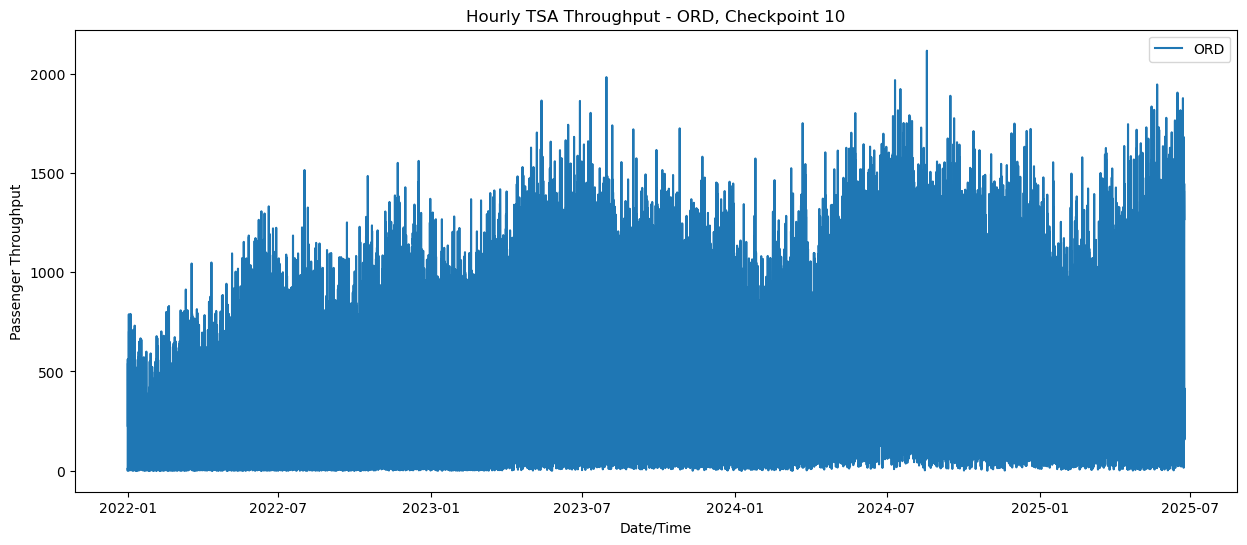

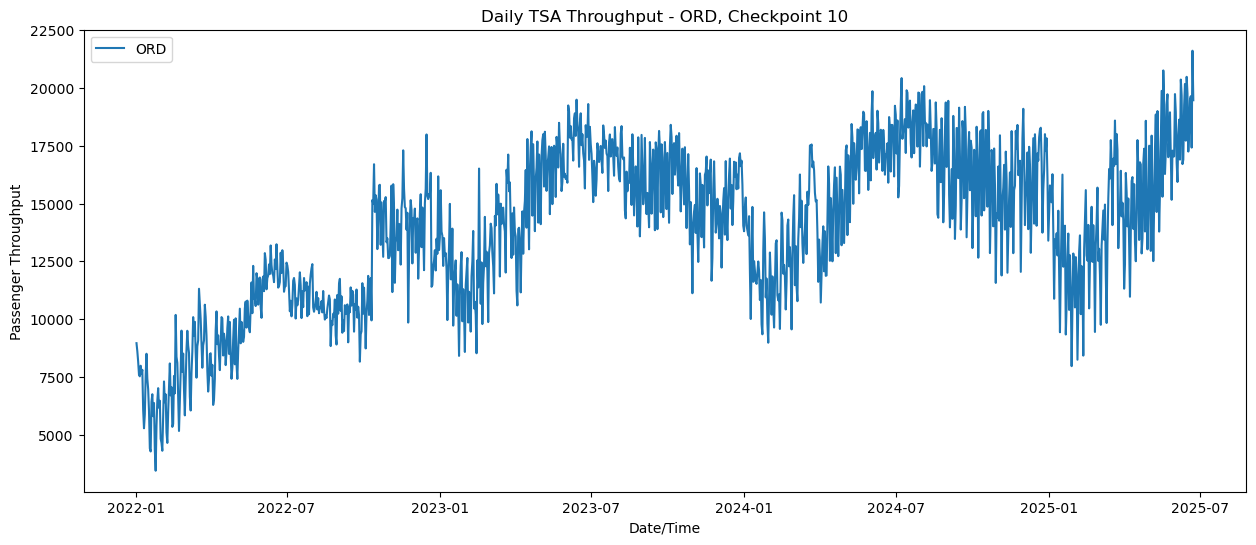

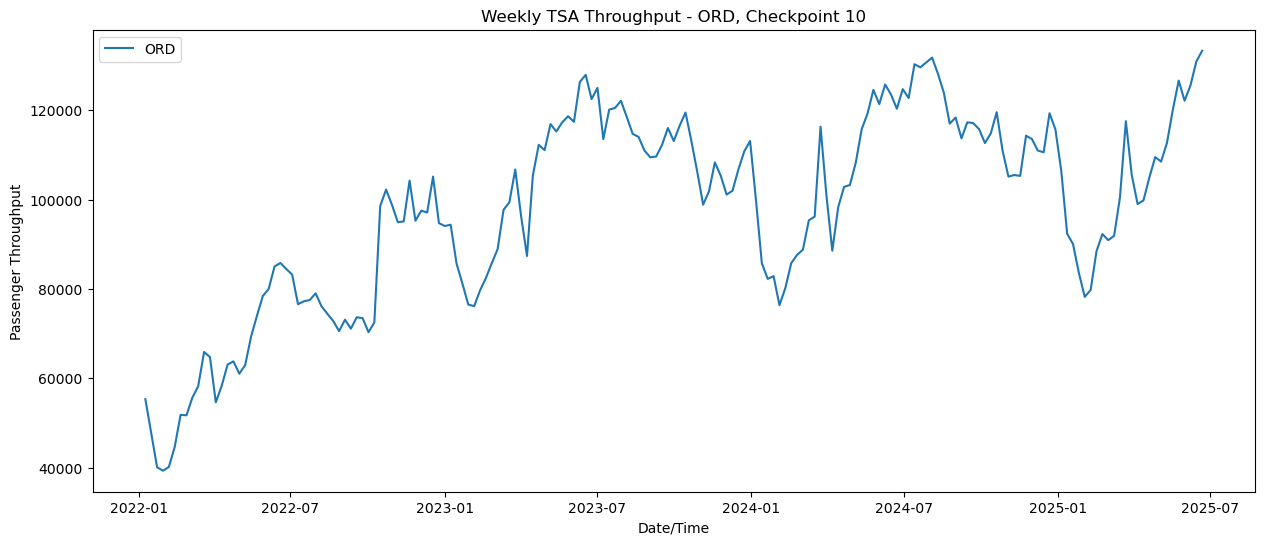

In [55]:
plot_airport_data(tsa_data, airport='ORD', frequency='H', checkpoint='10')
plot_airport_data(tsa_data, airport='ORD', frequency='D', checkpoint='10')
plot_airport_data(tsa_data, airport='ORD', frequency='W', checkpoint='10')

There are a few useful observations to make about this dataset. First of all, notice that the hourly data appears to be less useful than the daily and weekly data. Also notice that it is hard to observe a trend for the data from a single checkpoint, since this checkpoint may only be opened and closed during certain hours.

Next we can look at the airport as a whole:

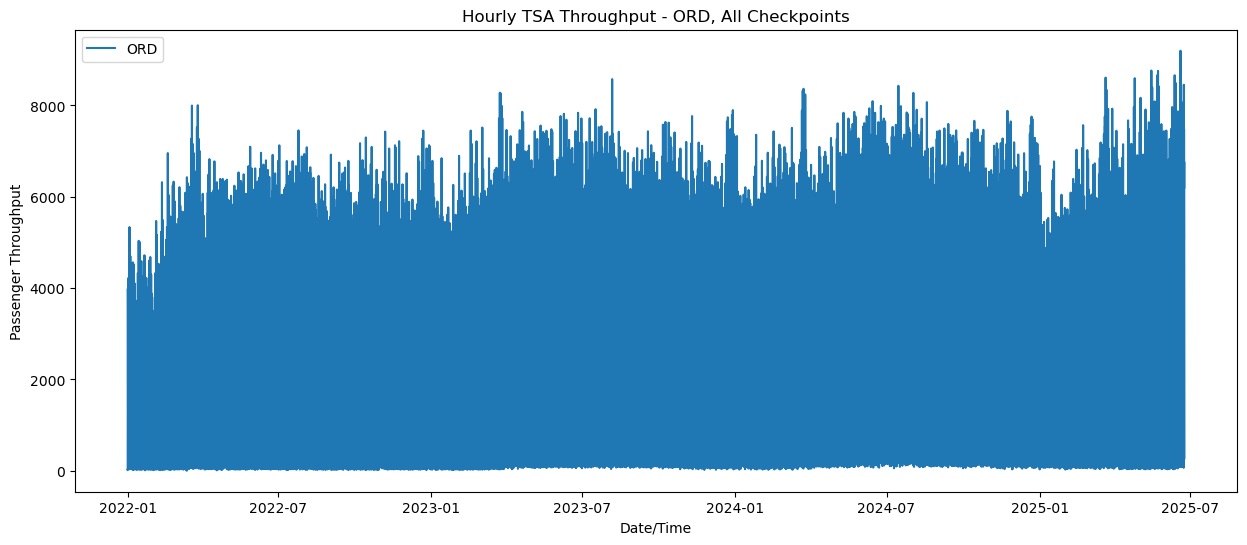

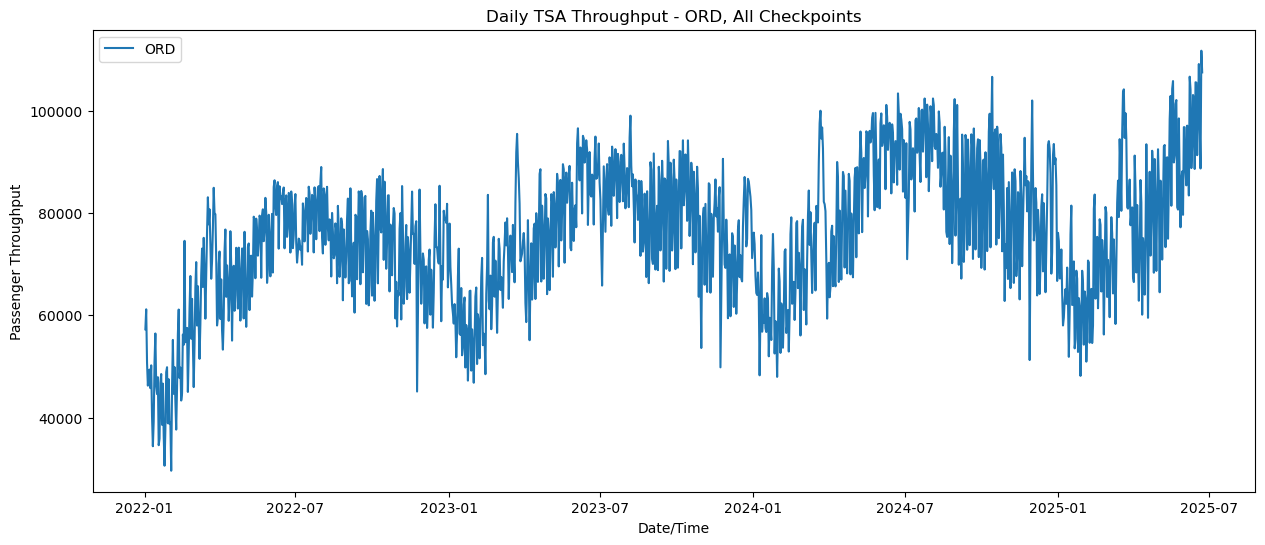

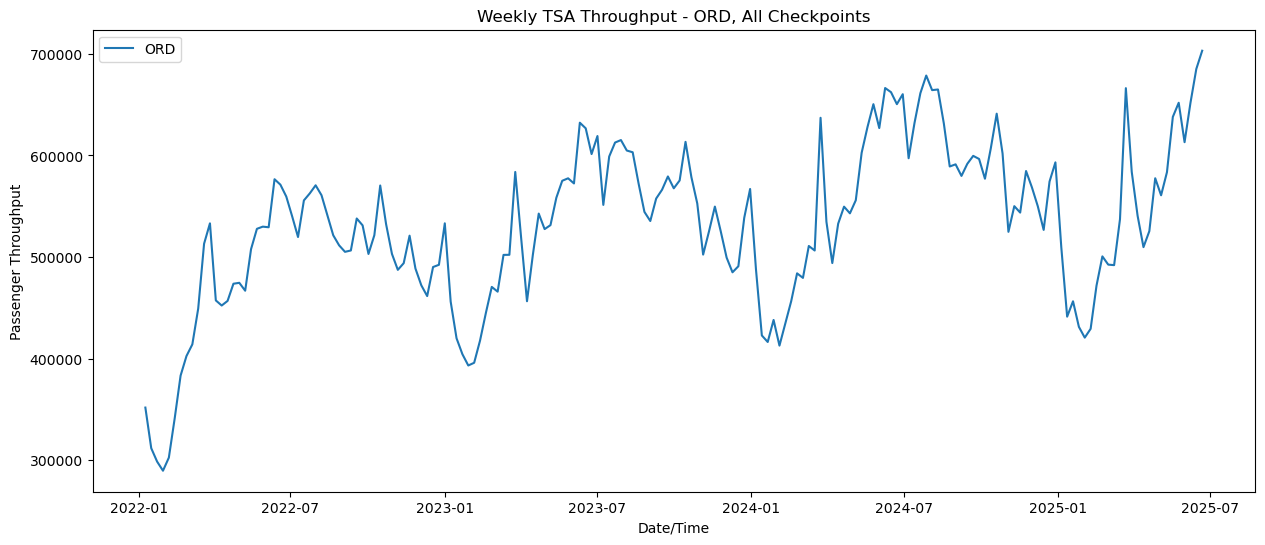

In [56]:
plot_airport_data(tsa_data, airport='ORD', frequency='H')
plot_airport_data(tsa_data, airport='ORD', frequency='D')
plot_airport_data(tsa_data, airport='ORD', frequency='W')

These plots clearly show that when considering all of the checkpoints, the throughput in an airport clearly shows annual seasonality and a linear trend. This can be further confirmed by looking at the autocorrelation and partial autocorrelation functions for the daily and weekly data.

We can also compare across multiple airports to verify that they carry the same trends.

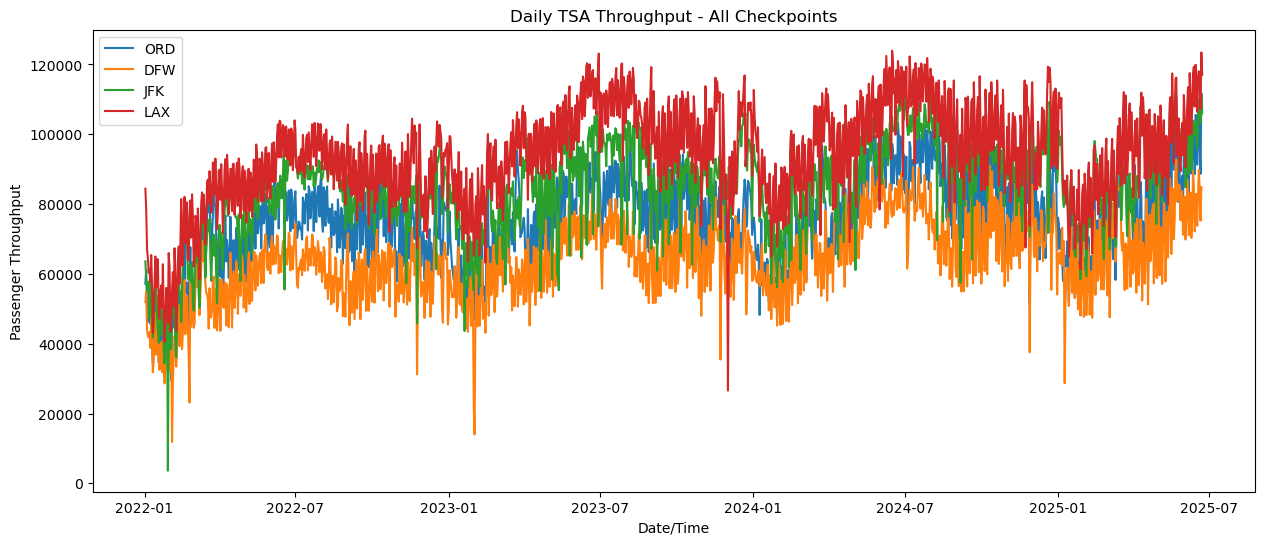

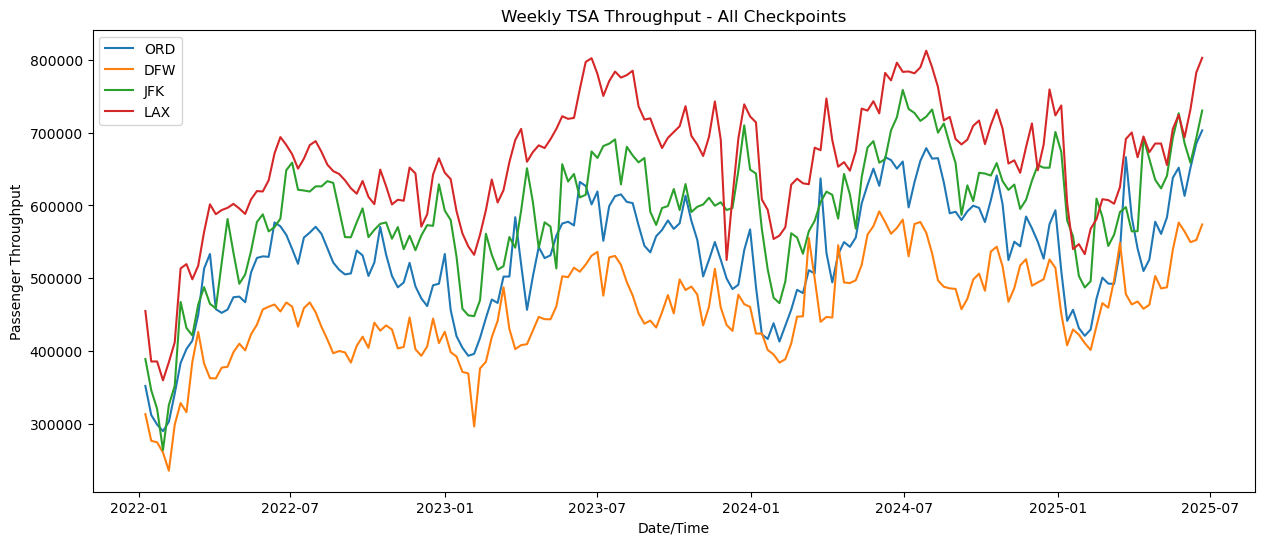

In [57]:
plot_airport_data(tsa_data, airport=['ORD','DFW','JFK','LAX'], frequency='D')
plot_airport_data(tsa_data, airport=['ORD','DFW','JFK','LAX'], frequency='W')

## ACF and PACF Plots

In [58]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [4]:
ord_daily = retrieve_airport_data(tsa_data, airport="ORD", frequency="D")
ord_weekly = retrieve_airport_data(tsa_data, airport="ORD", frequency="W")

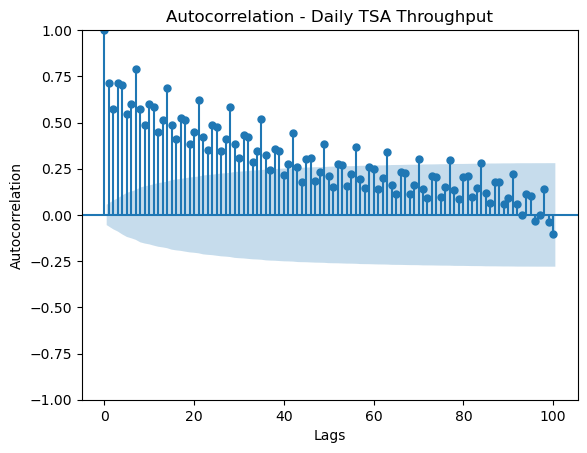

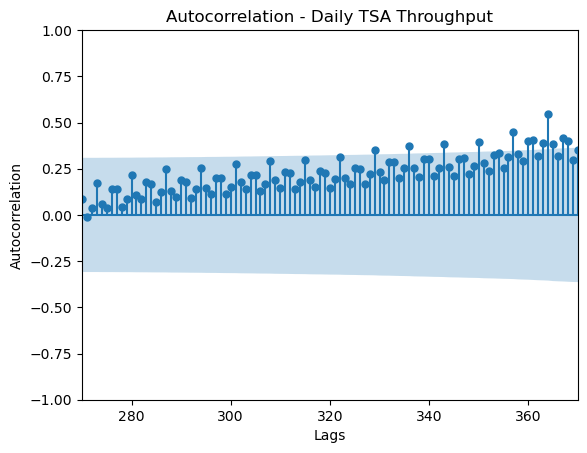

In [60]:
plot_acf(ord_daily.total_passenger_throughput, lags=100)
plt.title("Autocorrelation - Daily TSA Throughput")
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.show()
plot_acf(ord_daily.total_passenger_throughput, lags=370)
plt.title("Autocorrelation - Daily TSA Throughput")
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.xlim(270,370)
plt.show()

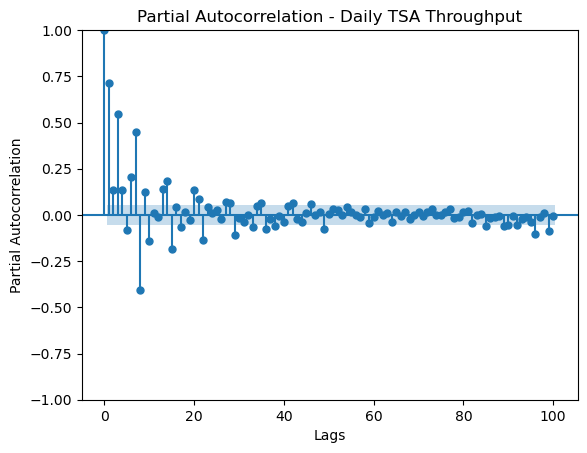

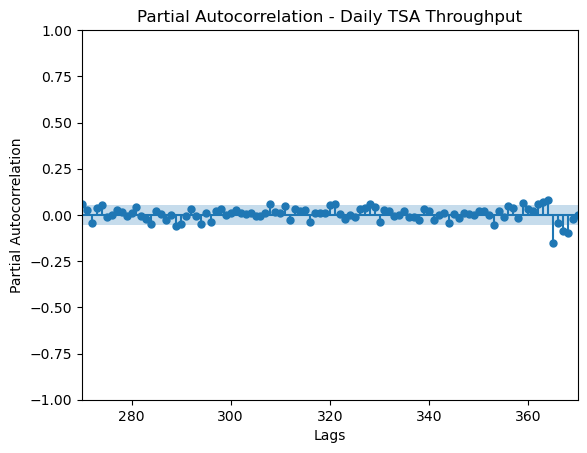

In [61]:
plot_pacf(ord_daily.total_passenger_throughput, lags=100)
plt.title("Partial Autocorrelation - Daily TSA Throughput")
plt.xlabel('Lags')
plt.ylabel('Partial Autocorrelation')
plt.show()
plot_pacf(ord_daily.total_passenger_throughput, lags=370)
plt.title("Partial Autocorrelation - Daily TSA Throughput")
plt.xlabel('Lags')
plt.ylabel('Partial Autocorrelation')
plt.xlim(270,370)
plt.show()

Here note from the autocorrelation that there is a large spike at every 7 lags and another large spike after 365 lags. This indicates both a weekly and annual seasonality in the daily data.

We can also look at the ACF and PACF for the weekly data.

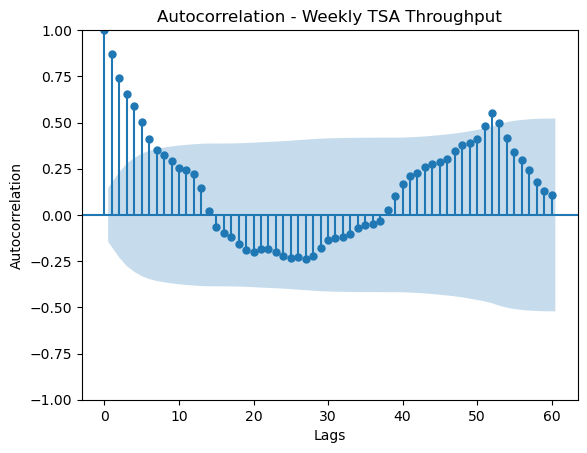

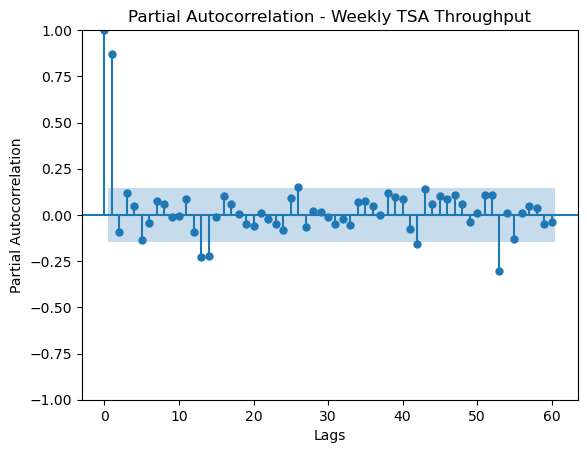

In [62]:
plot_acf(ord_weekly.total_passenger_throughput, lags=60)
plt.title("Autocorrelation - Weekly TSA Throughput")
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.show()
plot_pacf(ord_weekly.total_passenger_throughput, lags=60)
plt.title("Partial Autocorrelation - Weekly TSA Throughput")
plt.xlabel('Lags')
plt.ylabel('Partial Autocorrelation')
plt.show()

Here we observe that the dominant lags are the small lags (below about 5-6) and again there is annual seasonality indicated by a spike at lag 52.

Even though these models are clearly note stationary, we can model the seasonailty using either STL decomposition or SARIMA model, leaving the remaining residuals to be approximately stationary.

## Baseline Models

For our baseline models, we chose to use the Naive Seasonal Model with Drift and the Triple Exponential Smoothing model. These are simple enough models that are able to capture the annual seasonality and overall trend that we see in the throughput data.

In [5]:
from busy_airports.baselines import NaiveSeasonalWithDrift, TripleExponentialSmoothing
from busy_airports.metrics import evaluate_forecast

As a simple test of these models, we will create a train-test split with the last six months of data used to test the baseline models.

In [6]:
# daily train-test split
ord_daily_train = ord_daily[ord_daily['datetime'] < "2025-01-01"]
ord_daily_test  = ord_daily[ord_daily['datetime'] >= "2025-01-01"]
# weekly train-test split
ord_weekly_train = ord_weekly[ord_weekly['datetime'] < "2025-01-01"]
ord_weekly_test  = ord_weekly[ord_weekly['datetime'] >= "2025-01-01"]


Naive Seasonal with Drift:
  MAE: 11,681
  MAPE: 14.80%
  RMSE: 14,073


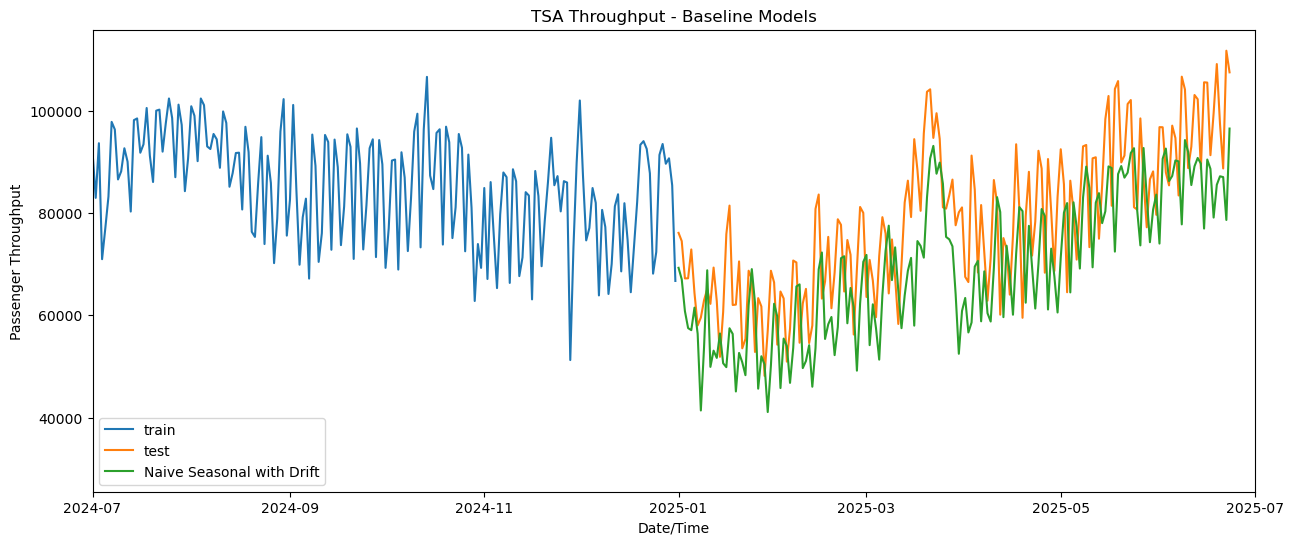

In [65]:
# Apply the Naive Seasonal model with Drift to the daily data and calculate metrics
nswd_model = NaiveSeasonalWithDrift(season_length=365)
nswd_model.fit(ord_daily_train.total_passenger_throughput)
nswd_forecast = nswd_model.forecast(h=len(ord_daily_test))
nswd_metrics = evaluate_forecast(ord_daily_test.total_passenger_throughput,
                                 nswd_forecast,
                                 "Naive Seasonal with Drift")
# Print metrics
print(f"\nNaive Seasonal with Drift:")
print(f"  MAE: {nswd_metrics['mae']:,.0f}")
print(f"  MAPE: {nswd_metrics['mape']*100:.2f}%")
print(f"  RMSE: {nswd_metrics['rmse']:,.0f}")
# Plot results
plt.figure(figsize=(15, 6))
plt.plot(ord_daily_train.datetime, ord_daily_train.total_passenger_throughput, label="train")
plt.plot(ord_daily_test.datetime, ord_daily_test.total_passenger_throughput, label="test")
plt.plot(ord_daily_test.datetime, nswd_forecast, label="Naive Seasonal with Drift")
plt.title("TSA Throughput - Baseline Models")
plt.xlabel('Date/Time')
plt.ylabel('Passenger Throughput')
plt.xlim(pd.Timestamp("2024-07-01"), pd.Timestamp("2025-07-01"))
plt.legend()
plt.show()


Triple Exponential Smoothing:
  MAE: 9,134
  MAPE: 12.47%
  RMSE: 11,468


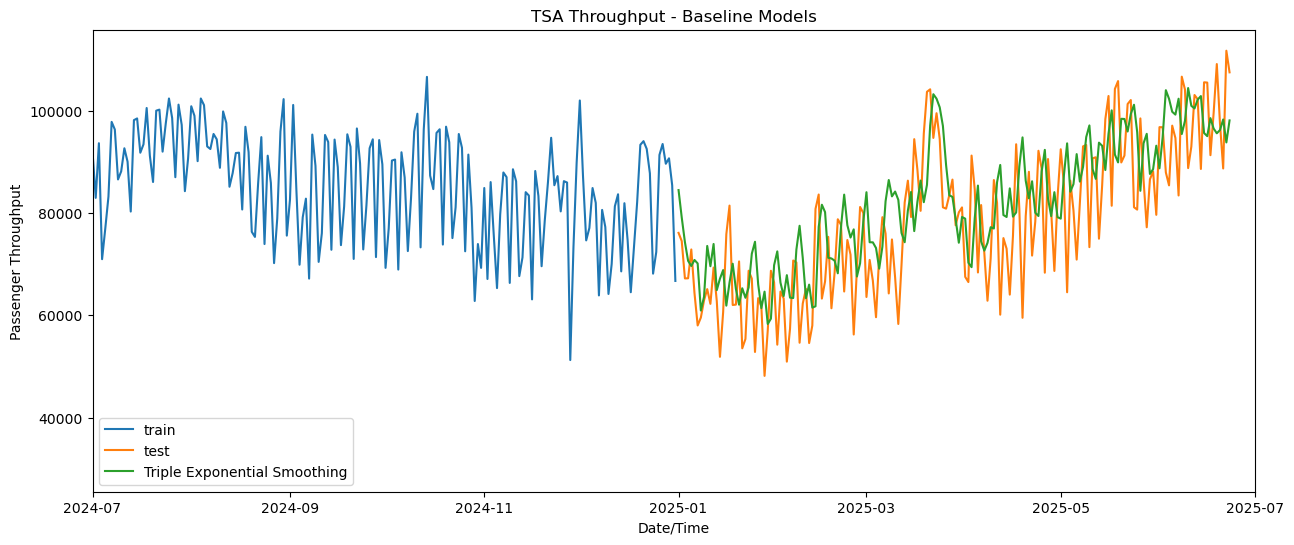

In [66]:
# Apply the Triple Exponential smoothing model to the daily data and calculate metrics
exps_model = TripleExponentialSmoothing(season_length=365)
exps_model.fit(ord_daily_train.total_passenger_throughput)
exps_forecast = exps_model.forecast(h=len(ord_daily_test))
exps_metrics = evaluate_forecast(ord_daily_test.total_passenger_throughput,
                                 exps_forecast,
                                 "Triple Exponential Smoothing")
# Print metrics
print(f"\nTriple Exponential Smoothing:")
print(f"  MAE: {exps_metrics['mae']:,.0f}")
print(f"  MAPE: {exps_metrics['mape']*100:.2f}%")
print(f"  RMSE: {exps_metrics['rmse']:,.0f}")
# Plot results
plt.figure(figsize=(15, 6))
plt.plot(ord_daily_train.datetime, ord_daily_train.total_passenger_throughput, label="train")
plt.plot(ord_daily_test.datetime, ord_daily_test.total_passenger_throughput, label="test")
plt.plot(ord_daily_test.datetime, exps_forecast, label="Triple Exponential Smoothing")
plt.title("TSA Throughput - Baseline Models")
plt.xlabel('Date/Time')
plt.ylabel('Passenger Throughput')
plt.xlim(pd.Timestamp("2024-07-01"), pd.Timestamp("2025-07-01"))
plt.legend()
plt.show()

It looks like the Triple Exponential model did slightly better on this testing set. This is the model that our custom model will need to beat.

Next let's repeat this process with the weekly throughput data.


Naive Seasonal with Drift:
  MAE: 22,580
  MAPE: 4.23%
  RMSE: 27,186


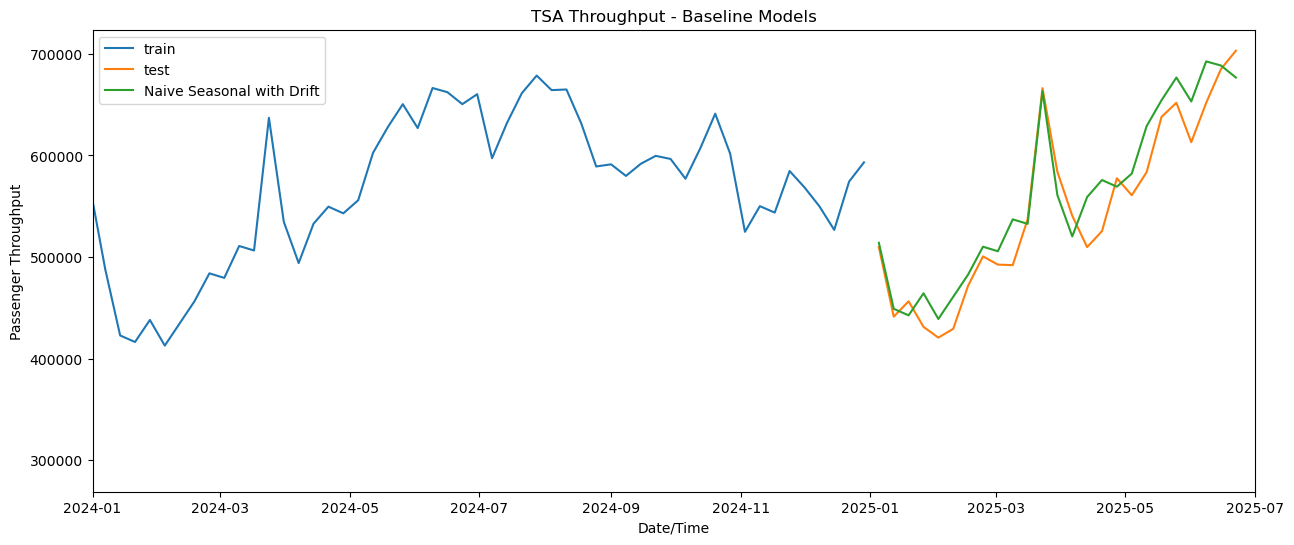

In [67]:
# Apply the Naive Seasonal model with Drift to the weekly data and calculate metrics
nswd_model = NaiveSeasonalWithDrift(season_length=52)
nswd_model.fit(ord_weekly_train.total_passenger_throughput)
nswd_forecast = nswd_model.forecast(h=len(ord_weekly_test))
nswd_metrics = evaluate_forecast(ord_weekly_test.total_passenger_throughput,
                                 nswd_forecast,
                                 "Naive Seasonal with Drift")
# Print metrics
print(f"\nNaive Seasonal with Drift:")
print(f"  MAE: {nswd_metrics['mae']:,.0f}")
print(f"  MAPE: {nswd_metrics['mape']*100:.2f}%")
print(f"  RMSE: {nswd_metrics['rmse']:,.0f}")
# Plot results
plt.figure(figsize=(15, 6))
plt.plot(ord_weekly_train.datetime, ord_weekly_train.total_passenger_throughput, label="train")
plt.plot(ord_weekly_test.datetime, ord_weekly_test.total_passenger_throughput, label="test")
plt.plot(ord_weekly_test.datetime, nswd_forecast, label="Naive Seasonal with Drift")
plt.title("TSA Throughput - Baseline Models")
plt.xlabel('Date/Time')
plt.ylabel('Passenger Throughput')
plt.xlim(pd.Timestamp("2024-01-01"), pd.Timestamp("2025-07-01"))
plt.legend()
plt.show()


Triple Exponential Smoothing:
  MAE: 27,809
  MAPE: 5.35%
  RMSE: 33,077


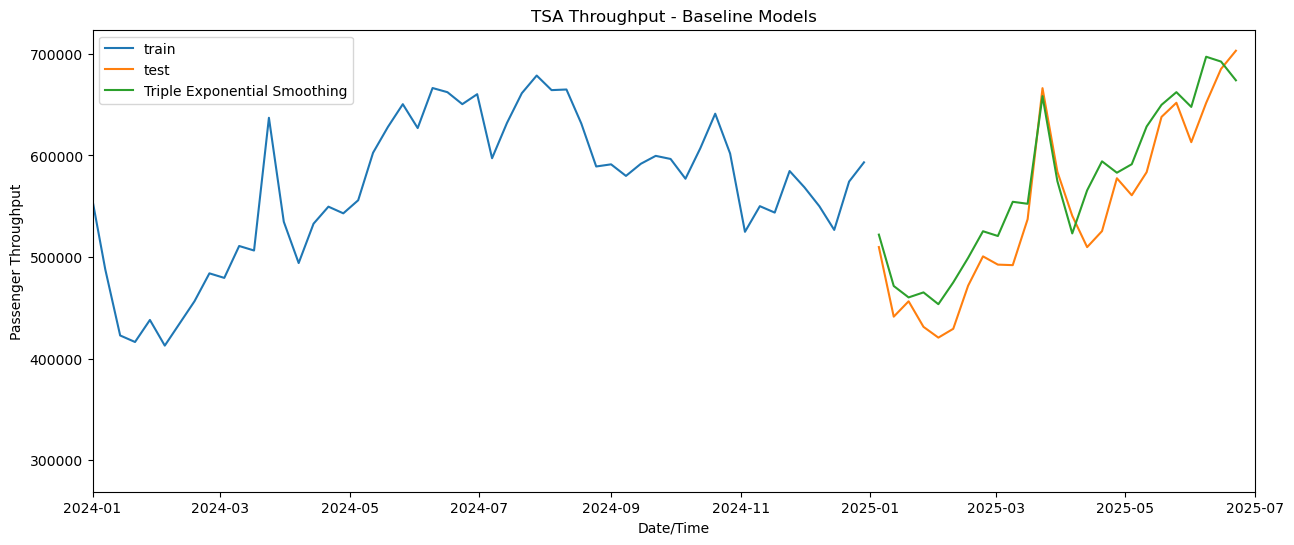

In [68]:
# Apply the Triple Exponential smoothing model to the daily data and calculate metrics
exps_model = TripleExponentialSmoothing(season_length=52)
exps_model.fit(ord_weekly_train.total_passenger_throughput)
exps_forecast = exps_model.forecast(h=len(ord_weekly_test))
exps_metrics = evaluate_forecast(ord_weekly_test.total_passenger_throughput,
                                 exps_forecast,
                                 "Triple Exponential Smoothing")
# Print metrics
print(f"\nTriple Exponential Smoothing:")
print(f"  MAE: {exps_metrics['mae']:,.0f}")
print(f"  MAPE: {exps_metrics['mape']*100:.2f}%")
print(f"  RMSE: {exps_metrics['rmse']:,.0f}")
# Plot results
plt.figure(figsize=(15, 6))
plt.plot(ord_weekly_train.datetime, ord_weekly_train.total_passenger_throughput, label="train")
plt.plot(ord_weekly_test.datetime, ord_weekly_test.total_passenger_throughput, label="test")
plt.plot(ord_weekly_test.datetime, exps_forecast, label="Triple Exponential Smoothing")
plt.title("TSA Throughput - Baseline Models")
plt.xlabel('Date/Time')
plt.ylabel('Passenger Throughput')
plt.xlim(pd.Timestamp("2024-01-01"), pd.Timestamp("2025-07-01"))
plt.legend()
plt.show()

Clearly with the weekly data the baseline models do a much better job of matching the trend. Here, the naive Seasonal with Drift model performs a bit better. This is the model we need to try to beat.

# Modelling Approach

## Data Splits

In [7]:
#creating splits
from busy_airports.data_splits import make_rolling_splits, make_rolling_splits_weekly

#Creating Daily Splits
splits_d = make_rolling_splits(ord_daily_train, date_col='datetime', n_splits=5, step_days=60)
#Creating Weekly Splits
splits_w = make_rolling_splits_weekly(ord_daily_train, date_col='datetime', n_splits=5, step_weeks=13)

Split 1: train → 2024-02-29 | test 2024-03-01 → 2024-04-29 (60 days)
Split 2: train → 2024-04-29 | test 2024-04-30 → 2024-06-28 (60 days)
Split 3: train → 2024-06-28 | test 2024-06-29 → 2024-08-27 (60 days)
Split 4: train → 2024-08-27 | test 2024-08-28 → 2024-10-26 (60 days)
Split 5: train → 2024-10-26 | test 2024-10-27 → 2024-12-25 (60 days)
Split 1: train → row 116 (2022-04-28) | test rows 117–129 (2022-04-29 → 2022-05-11) (13 weeks)
Split 2: train → row 129 (2022-05-11) | test rows 130–142 (2022-05-12 → 2022-05-24) (13 weeks)
Split 3: train → row 142 (2022-05-24) | test rows 143–155 (2022-05-25 → 2022-06-06) (13 weeks)
Split 4: train → row 155 (2022-06-06) | test rows 156–168 (2022-06-07 → 2022-06-19) (13 weeks)
Split 5: train → row 168 (2022-06-19) | test rows 169–181 (2022-06-20 → 2022-07-02) (13 weeks)


## STLArima

In [8]:
from busy_airports.models import STLArima
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima

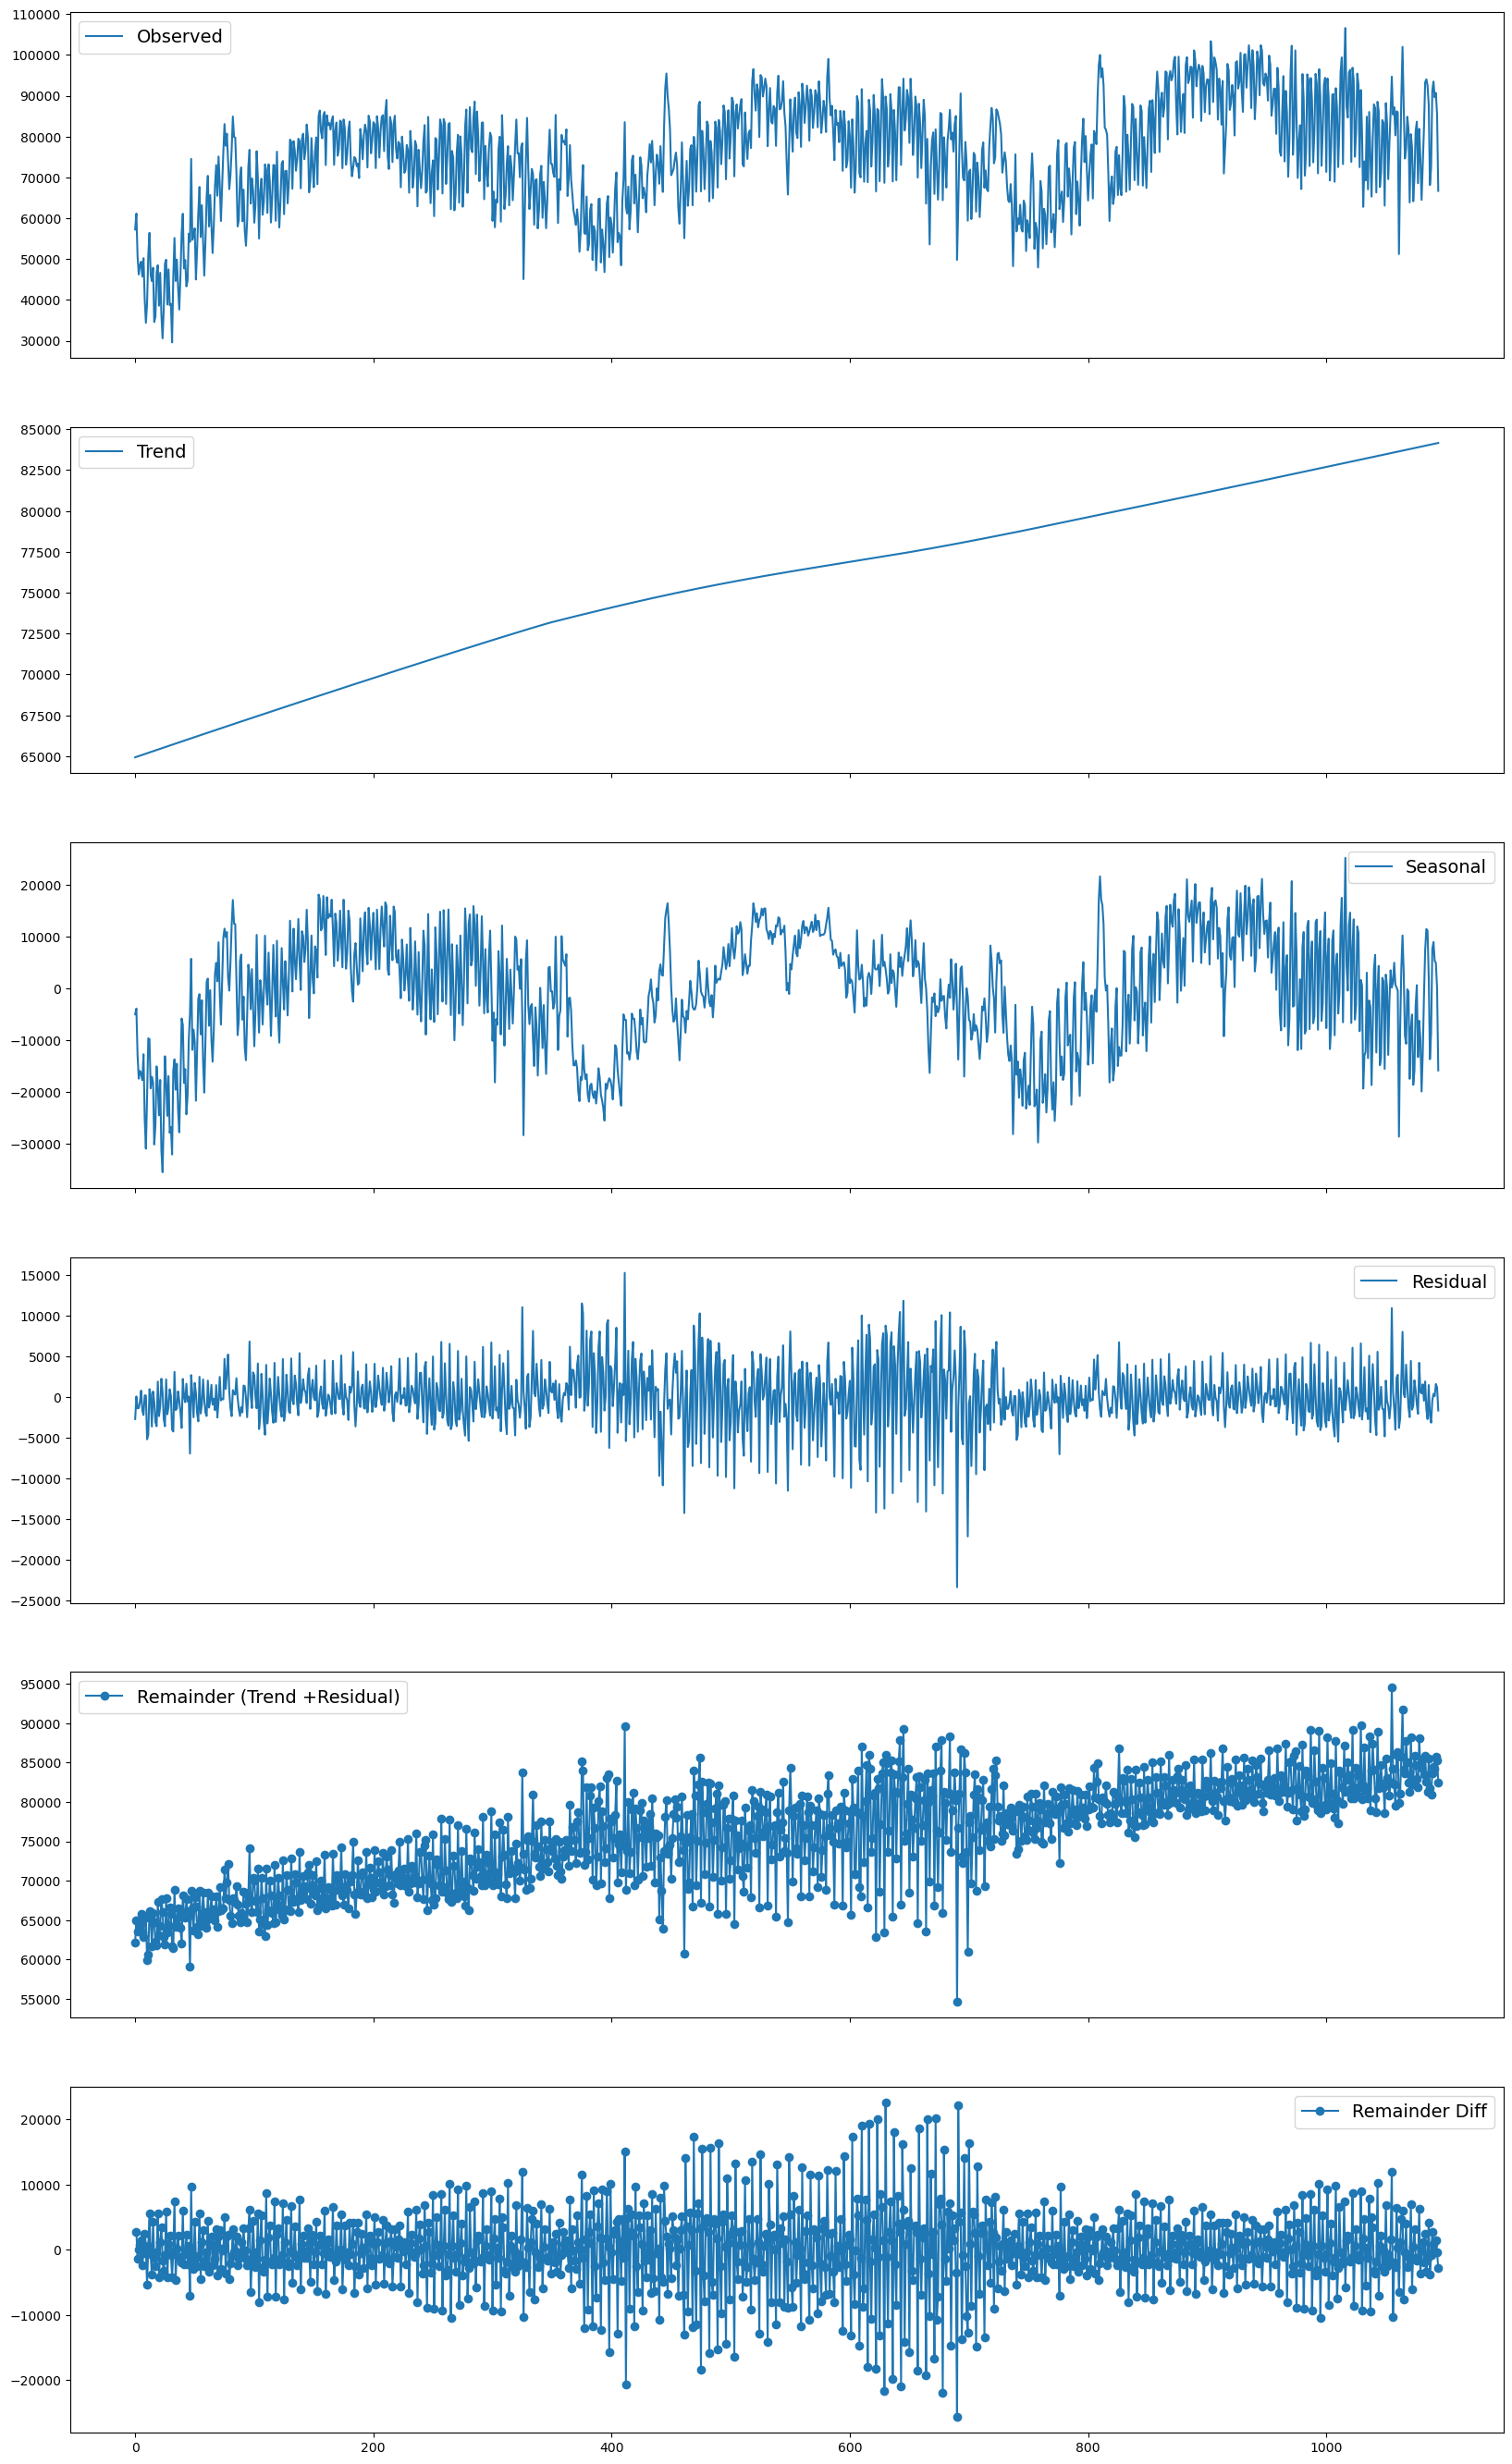

In [ ]:
# Obtain the auto arima model fitted to the training set (effectively does cross validation to select optimal hyperparameters)
stl_daily = STL(ord_daily_train['total_passenger_throughput'], period=365)
stl_daily_results = stl_daily.fit()

stl_daily_trend = stl_daily_results.trend
stl_daily_seasonal = stl_daily_results.seasonal
stl_daily_resid = stl_daily_results.resid
stl_daily_base = stl_daily_results.observed

stl_daily_trend_diff = stl_daily_trend.diff()
stl_daily_remainder = stl_daily_trend + stl_daily_resid
stl_daily_remainder_diff = stl_daily_remainder.diff()

fig, ax = plt.subplots(6, 1, figsize=(20, 34), sharex=True)
ax[0].plot(stl_daily_base, label='Observed')
ax[0].legend(fontsize=14)
ax[1].plot(stl_daily_trend, label='Trend')
ax[1].legend(fontsize=14)
ax[2].plot(stl_daily_seasonal, label='Seasonal')
ax[2].legend(fontsize=14)
ax[3].plot(stl_daily_resid, label='Residual')
ax[3].legend(fontsize=14)
ax[4].plot(stl_daily_remainder, label='Remainder (Trend +Residual)', marker='o')
ax[4].legend(fontsize=14)
ax[5].plot(stl_daily_remainder_diff, label='Remainder Diff', marker='o')
ax[5].legend(fontsize=14)
plt.show()

'''
auto_arima(stl_daily_remainder, 
           seasonal=True,
           trace = True, 
           m=7, 
           stepwise=True, 
           suppress_warnings=True, 
           error_action='ignore')
'''


```
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=20712.220, Time=1.06 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=22102.268, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=21292.591, Time=0.28 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=21057.601, Time=0.43 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=22100.280, Time=0.01 sec
 ARIMA(2,1,2)(0,0,1)[7] intercept   : AIC=20975.384, Time=0.70 sec
 ARIMA(2,1,2)(1,0,0)[7] intercept   : AIC=20844.879, Time=0.76 sec
 ARIMA(2,1,2)(2,0,1)[7] intercept   : AIC=20710.122, Time=1.81 sec
 ARIMA(2,1,2)(2,0,0)[7] intercept   : AIC=20784.277, Time=1.61 sec
 ARIMA(2,1,2)(2,0,2)[7] intercept   : AIC=inf, Time=2.27 sec
 ARIMA(2,1,2)(1,0,2)[7] intercept   : AIC=20710.612, Time=1.70 sec
 ARIMA(1,1,2)(2,0,1)[7] intercept   : AIC=20901.631, Time=1.27 sec
 ARIMA(2,1,1)(2,0,1)[7] intercept   : AIC=20683.433, Time=1.58 sec
 ARIMA(2,1,1)(1,0,1)[7] intercept   : AIC=20685.749, Time=0.92 sec
 ARIMA(2,1,1)(2,0,0)[7] intercept   : AIC=inf, Time=1.48 sec
 ARIMA(2,1,1)(2,0,2)[7] intercept   : AIC=inf, Time=1.57 sec
 ARIMA(2,1,1)(1,0,0)[7] intercept   : AIC=20803.316, Time=0.68 sec
 ARIMA(2,1,1)(1,0,2)[7] intercept   : AIC=20683.779, Time=1.48 sec
 ARIMA(1,1,1)(2,0,1)[7] intercept   : AIC=20815.982, Time=1.20 sec
 ARIMA(2,1,0)(2,0,1)[7] intercept   : AIC=20863.331, Time=1.29 sec
 ARIMA(3,1,1)(2,0,1)[7] intercept   : AIC=20673.747, Time=1.97 sec
 ARIMA(3,1,1)(1,0,1)[7] intercept   : AIC=20675.032, Time=0.99 sec
 ARIMA(3,1,1)(2,0,0)[7] intercept   : AIC=20756.788, Time=1.40 sec
 ARIMA(3,1,1)(2,0,2)[7] intercept   : AIC=inf, Time=2.21 sec
...
 ARIMA(4,1,3)(1,0,2)[7]             : AIC=20616.764, Time=2.57 sec

Best model:  ARIMA(5,1,4)(1,0,2)[7]          
Total fit time: 178.432 seconds
```

In [9]:
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning)

#Arima orders for the remainder component of the STL decomposition
#OLD: Best model:  ARIMA(5,1,2)(2,0,1)[7] 
#NEW: Best model:  ARIMA(5,1,4)(1,0,2)[7]

p, d, q = 5, 1, 2
P, D, Q, s = 1, 0, 2, 7

results_stl_d=[]
#Running STL + ARIMA on daily data using the splits created above.
for i, (train_idx, test_idx) in enumerate(splits_d):
        if len(test_idx) == 0:
            print(f"Split {i+1}: empty test set, skipping")
            continue

        train = ord_daily_train.loc[train_idx].copy()
        test  = ord_daily_train.loc[test_idx].copy()
        n_forecast = len(test_idx)
        model = STLArima(season_length=365,arima_order=(p,d,q), seasonal_order=(P,D,Q,s))
        model.fit(train['total_passenger_throughput'])
        forecasts, lower_bound, upper_bound = model.forecast(n_forecast)
        actuals  = test['total_passenger_throughput'].values
        metrics = evaluate_forecast(actuals, forecasts, model_name=f"Split {i+1}")
        metrics['split'] = i + 1
        results_stl_d.append(metrics)
        print(f"Split {i+1} - MAE: {metrics['mae']:.0f}, MAPE: {100*metrics['mape']:.2f}%, RMSE: {metrics['rmse']:.0f}")

results_stl_d_df = pd.DataFrame(results_stl_d).set_index('split')
print("\nCV Average:")
print(f"  MAE:  {results_stl_d_df['mae'].mean():,.0f}")
print(f"  MAPE: {results_stl_d_df['mape'].mean()*100:.2f}%")
print(f"  RMSE: {results_stl_d_df['rmse'].mean():,.0f}")  



Split 1 - MAE: 8312, MAPE: 11.31%, RMSE: 9976
Split 2 - MAE: 8028, MAPE: 8.96%, RMSE: 9832
Split 3 - MAE: 7684, MAPE: 8.60%, RMSE: 9582
Split 4 - MAE: 11218, MAPE: 13.81%, RMSE: 13819
Split 5 - MAE: 10485, MAPE: 13.65%, RMSE: 13494

CV Average:
  MAE:  9,145
  MAPE: 11.27%
  RMSE: 11,341


In [10]:
ord_daily_train = ord_daily_train.set_index('datetime')
ord_daily_train.index = pd.to_datetime(ord_daily_train.index)

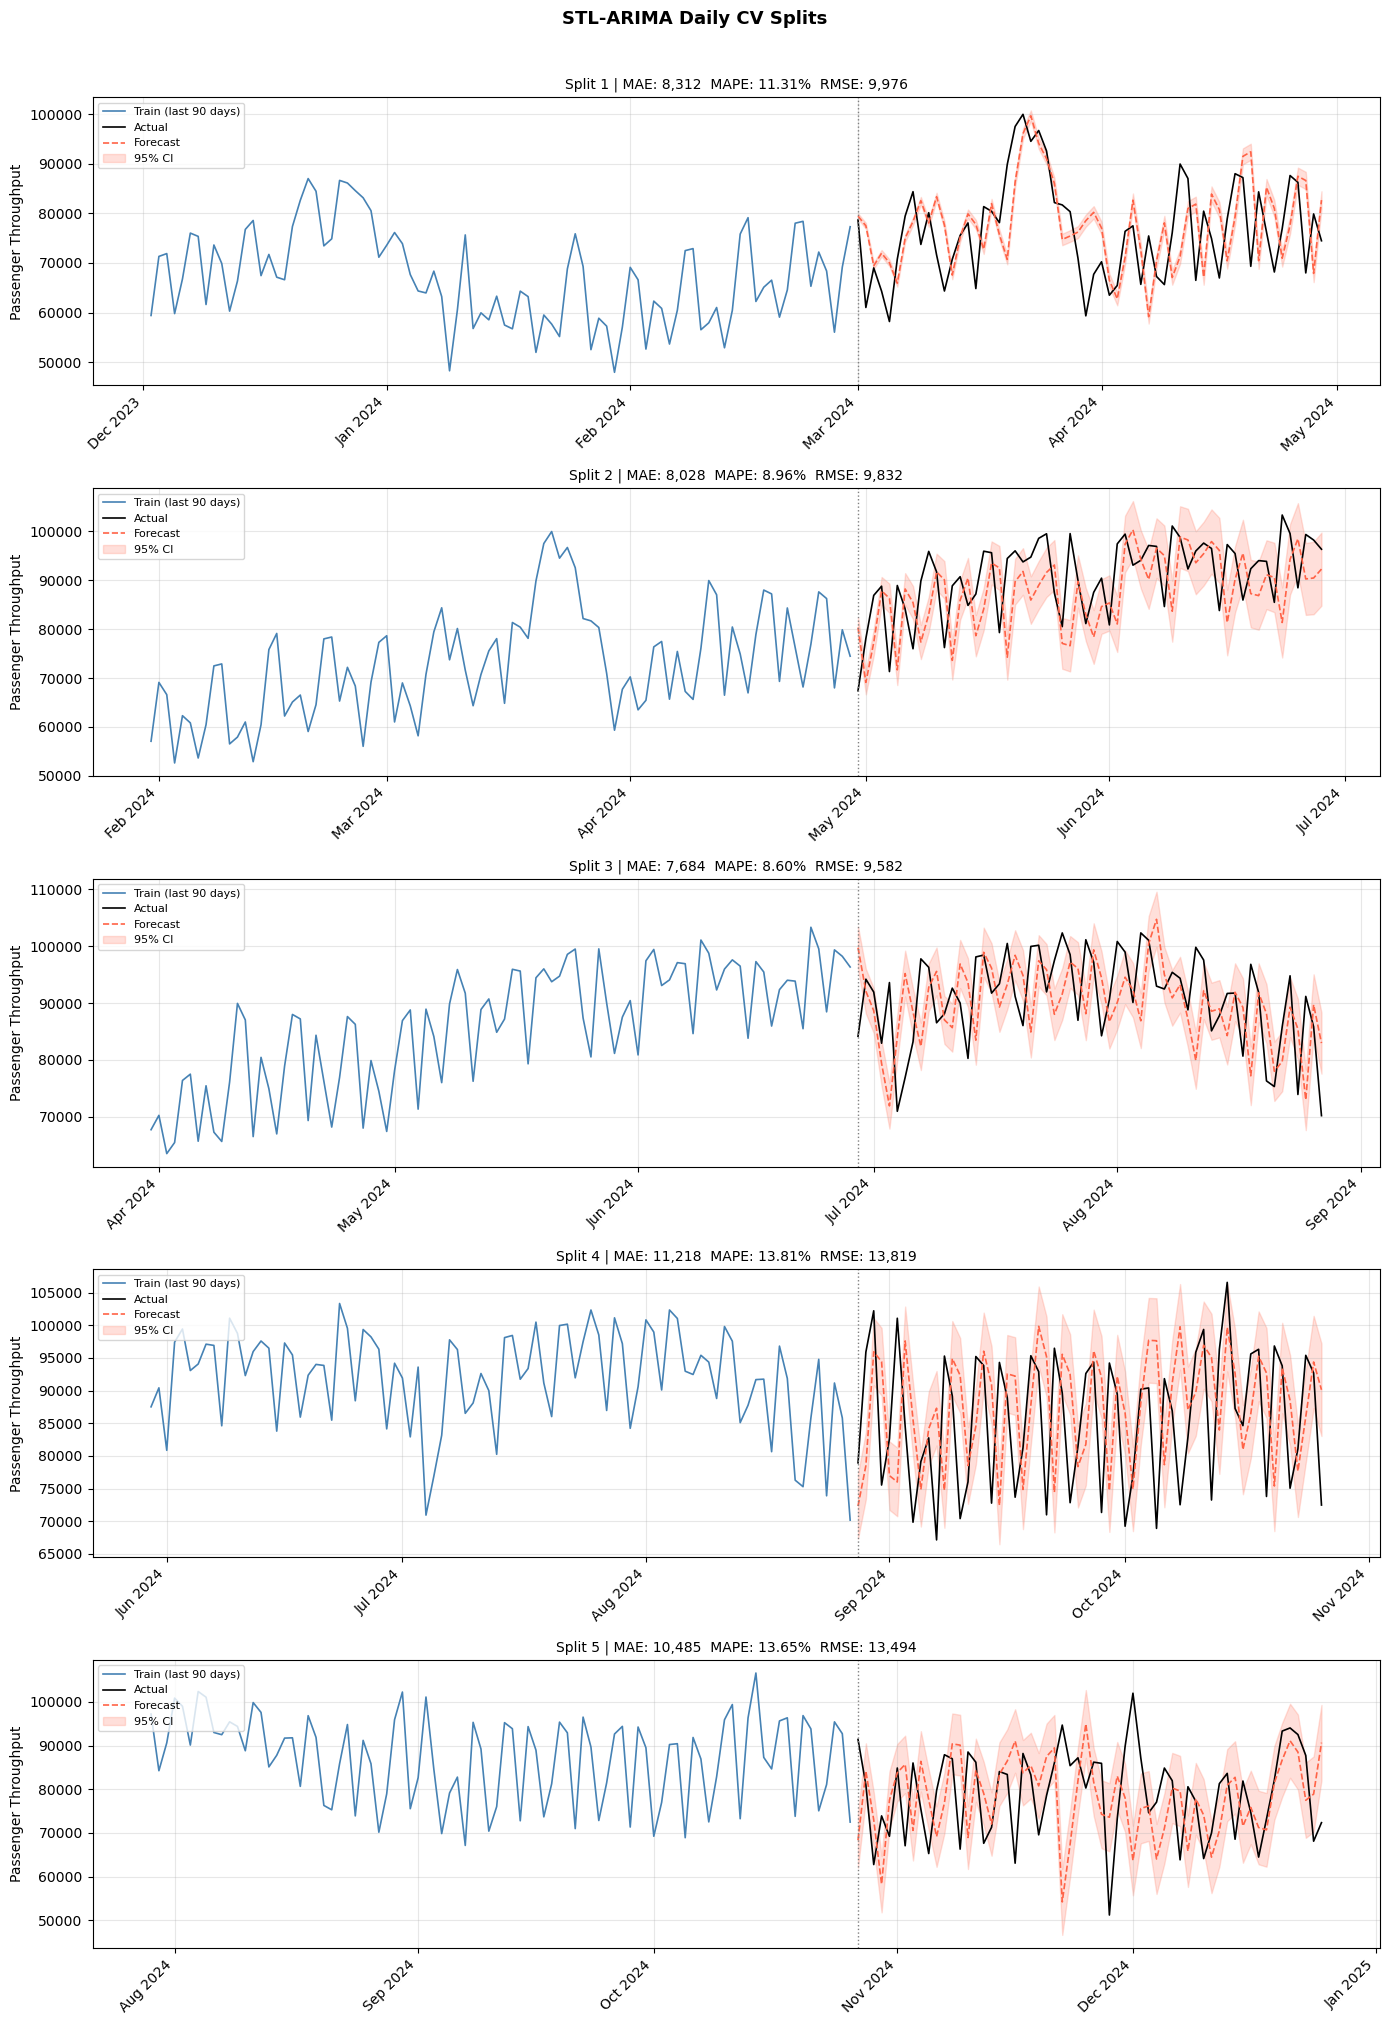

In [11]:
import matplotlib.dates as mdates

fig, axes = plt.subplots(len(splits_d), 1, figsize=(14, 4 * len(splits_d)))
axes = axes if hasattr(axes, '__len__') else [axes]  # handle single split edge case

for i, (train_idx, test_idx) in enumerate(splits_d):
    ax = axes[i]

    if len(test_idx) == 0:
        print(f"Split {i+1}: empty test set, skipping")
        ax.set_visible(False)
        continue

    train = ord_daily_train.iloc[train_idx].copy()
    test  = ord_daily_train.iloc[test_idx].copy()
    n_forecast = len(test_idx)

    model = STLArima(season_length=365, arima_order=(p,d,q), seasonal_order=(P,D,Q,s))
    model.fit(train['total_passenger_throughput'])
    forecasts, lower_bound, upper_bound = model.forecast(n_forecast)

    actuals = test['total_passenger_throughput'].values
    metrics = evaluate_forecast(actuals, forecasts, model_name=f"Split {i+1}")
    metrics['split'] = i + 1
    results_stl_d.append(metrics)

    # --- Plotting ---
    train_dates = train.index
    test_dates  = test.index

    # Plot last N days of training data for context
    context_window = min(90, len(train))
    ax.plot(train_dates[-context_window:],
            train['total_passenger_throughput'].values[-context_window:],
            color='steelblue', label='Train (last 90 days)', linewidth=1.2)

    # Actuals in test window
    ax.plot(test_dates, actuals,
            color='black', label='Actual', linewidth=1.2)

    # Forecast
    ax.plot(test_dates, forecasts,
            color='tomato', label='Forecast', linewidth=1.2, linestyle='--')

    # 95% Confidence interval
    ax.fill_between(test_dates, lower_bound, upper_bound,
                    color='tomato', alpha=0.2, label='95% CI')

    # Vertical line separating train/test
    ax.axvline(x=test_dates[0], color='gray', linestyle=':', linewidth=1)

    ax.set_title(
        f"Split {i+1} | MAE: {metrics['mae']:,.0f}  "
        f"MAPE: {100*metrics['mape']:.2f}%  "
        f"RMSE: {metrics['rmse']:,.0f}",
        fontsize=10
    )
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax.legend(loc='upper left', fontsize=8)
    ax.set_ylabel('Passenger Throughput')
    ax.grid(True, alpha=0.3)

plt.suptitle('STL-ARIMA Daily CV Splits', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
#plt.savefig('stl_arima_cv_splits.png', dpi=150, bbox_inches='tight')
plt.show()
